# Weekly assignment 5

## Read before you start

* Provide clear and complete answers in code blocks or markdown. You may add as many as you need.
* Always motivate your answers. This can be done in markdown cells, or in comments in code.
* Submit your results via Brightspace. Use the following filename convention: ``StudentName1_snumber1_StudentName2_snumber2_Assignment5.ipynb``.
* Make sure you submit a fully executed version of the notebook file. The teaching assistants will not run/debug your code during grading.
* Questions? Ask them during the workgroups, or see Brightspace for instructions on how to proceed.

__IMPORTANT__

This submission requires some images (plots or diagrams). Make sure your figures are actually embedded in the notebook
file, and do not reference something local on your machine!

In [7]:
!apt-get update
!apt install jags -y
!pip install pyjags

Get:1 http://deb.debian.org/debian bullseye InRelease [116 kB]
Get:2 http://deb.debian.org/debian-security bullseye-security InRelease [27.2 kB]
Get:3 http://deb.debian.org/debian bullseye-updates InRelease [44.1 kB]
Get:4 http://deb.debian.org/debian bullseye/main amd64 Packages [8,066 kB]
Get:5 http://deb.debian.org/debian-security bullseye-security/main amd64 Packages [350 kB]
Get:6 http://deb.debian.org/debian bullseye-updates/main amd64 Packages [18.8 kB]
Fetched 8,622 kB in 1s (6,688 kB/s)




The following additional packages will be installed:
  libblas3 libgfortran5 liblapack3
The following NEW packages will be installed:
  jags libblas3 libgfortran5 liblapack3
0 upgraded, 4 newly installed, 0 to remove and 26 not upgraded.
Need to get 4,613 kB of archives.
After this operation, 14.0 MB of additional disk space will be used.
Get:1 http://deb.debian.org/debian bullseye/main amd64 libblas3 amd64 3.9.0-3+deb11u1 [153 kB]
Get:2 http://deb.debian.org/debian bullseye/main amd64 libg

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pyjags as pj

print('Using PyJAGS v{:s}'.format(pj.__version__))

plt.rc('axes', titlesize=18)        # fontsize of the axes title
plt.rc('axes', labelsize=18)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)       # fontsize of the tick labels
plt.rc('ytick', labelsize=14)       # fontsize of the tick labels
plt.rc('legend', fontsize=12)       # legend fontsize
plt.rc('figure', titlesize=30)      # fontsize of the figure title

Using PyJAGS v1.3.8


# Understanding the gravity of the situation

A large physics consortium consisting of $M=20$ labs from all around the world have come together to once and for all determine the true value of the Earth's gravity $g$ (which we generally think of as $g=9.81m/s^2$). 

However, the different labs use different techniques to measure $g$, each with their own biases and variances. They therefore need a hierarchical Bayesian model to integrate all their observations and try and find the best possible estimate. At the same time, such a model can inform us about how reliable the observations of different labs are.

Of course, you are the consultant with the task to construct and apply this model.

## Data

First of all, the data. To make things easy, each lab performs $N=10$ observations, which are indicated by $x_{ij}$; this shows observation $j$ for lab $i$.

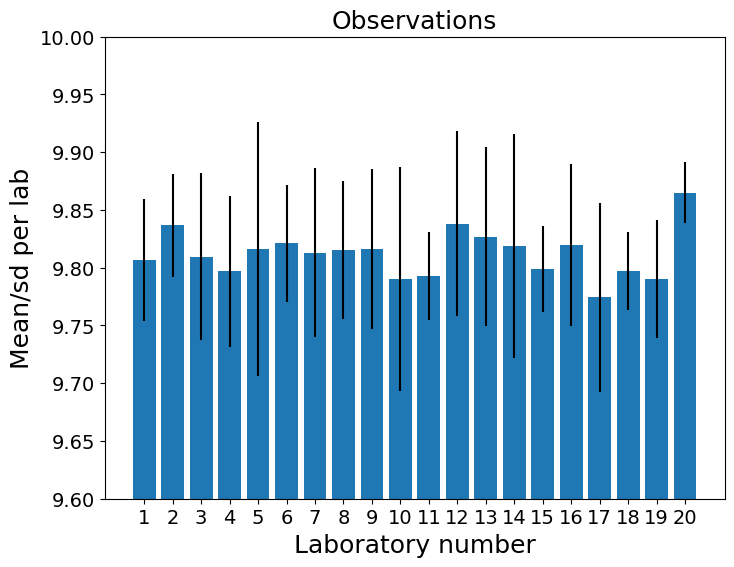

In [19]:
x = np.loadtxt('gravity_data.csv', delimiter=',')
M, N = x.shape # M - колво лабораторий (строки в таблице) # N - колво наблюдений в каждой лаборатории(столбцы)

plt.figure(figsize=(8, 6))
plt.bar(np.arange(M)+1, np.mean(x, axis=1), yerr=np.std(x, axis=1))
# - По оси X — номера лабораторий (от 1 до M)
# - По оси Y — среднее значение измерений в каждой лаборатории
# - Ошибки (yerr) — стандартное отклонение измерений в каждой лаборатории

plt.xticks(np.arange(M)+1)
plt.ylim([9.6, 10.0])
plt.xlabel('Laboratory number')
plt.ylabel('Mean/sd per lab')
plt.title('Observations');

Some labs stand out. For example, the last lab seems to be biased towards larger estimates of $g$. This bias is very consistent; its variability is small. Probably, something went wrong with the machinery here.

1. How could hierarchical Bayesian modelling help with this issue?

Hierarchical Bayesian modeling allows for both variation within laboratories and variation between laboratories.

Hierarchical Bayesian modelling will allow to combine measurements from all laboratories, taking into account their spread(reduces variance in estimates and increase robustness vs. outliers).
Laboratories with large deviations(theta_i) will "deviate" towards the overall result(theta_hat).
We will be able to assess the reliability of individual laboratories.

The hierarchical model allows you to separate the overall estimate g (global parameter) and the individual deviations of each laboratory (local parameters θi). This helps to account for differences between laboratories, correct biases, if any, and evaluate the reliability of each laboratory's data based on its consistency with others.

Thus, the hierarchical model allows you to "average" the data, taking into account their reliability, which is especially useful in the presence of outliers or systematic errors.

## The model

We will now start constructing the hierarchical Bayesian model step by step.

At the first level of the model, we need to combine the $N$ observations of each single lab $i$ to get the estimate of that lab, $\theta_i$, as well as to learn the standard deviation of the observations of that lab, $\sigma_i$. To do so, we must define the likelihoods $p(x_{ij} \mid \theta_i, \sigma_i)$. 

2. What is a sensible distribution to model $p(x_{ij} \mid \theta_i, \sigma_i)$ with? Motivate your choice.

A Normal (Gaussian) distribution is a reasonable choice because measurements are usually normally distributed with some mean θi and standard deviation σi. 
x_ij​ ∼ N(θi​,σi^2​) with 
- θi — the true value of g for laboratory i,
- σi is the standard deviation of measurements in laboratory i.

*lec3:
 p(xi|μ,σ) = Gaussian(xi |μ,σ ) where xi is the measurement, μ is the mean, and σ is the standard deviation.
 Gaussian(xi |μ,σ )= 1/sqrt(2*pi*σ^2) * exp(-(xi-μ)^2/(2*σ^2))

The parameters $\theta_i$ represent the best estimates for $g$ for each individual lab. However, in hierarchical Bayesian modelling, we are interested in not only effects per lab, but particularly in the 'global' effect that we estimate based on the data for all $M$ labs. 

To do this, we need a prior $p(\theta_i \mid \ldots)$. The parameters of this prior represent the __global__ estimate $\mu_\theta$, and its __standard deviation__ $\sigma_\theta$. 

3. What is a sensible distribution for $p(\theta_i \mid \mu_\theta, \sigma_\theta)$?

Normal distribution:
θi∼N(μ_θ,σ_θ^2),with
- μθ is the global average value of g over all labs(M)
- σθ is the standard deviation between laboratories

The normal distribution allows for variation between laboratories.
It assumes that the true values of θi are grouped around a common mean of μθ​.
It is symmetrical and allows for both positive and negative deviations from the true value.

Since we actually want to __know__ the global estimate and variability between the labs, we need to learn $\mu_\theta$ and $\sigma_\theta$ (if we did not, we wouldn't have a hierarchical model). This means these parameters too need to be specified a prior. The parameters of _these_ priors are hyperparameters that we will set manually.

4. Which prior distributions make sense for $\mu_\theta$ and which for $\sigma_\theta$, and why? 


For μ0:
μθ is the global average, and the normal distribution allows for a priori expectations.
Normal distribution:
μθ∼N(μ_θ ,σ_θ ^2),with
- μθ  is the expected value of g (9.81)
- σθ  is a large enough number (for example, 1) to account for the uncertainty
N(9.81, 01)

For σθ :
Gamma distribution (or a Semi-normal(halfNormal) distribution) to ensure the positivity of the variance.
σθ​∼Gamma(α,β),with
- α (shape) controls the shape of the distribution
- β (reverse scale) controls the "width" of the distribution

*Gamma(1,λ)=Exponential(λ)
if you sum n independent Exponential(λ) random variables, then you will get a Gamma(n,λ) random variable*

5. Repeat the question above for $\sigma_i$, the variance of the measurements of lab $i$. What is a sensible prior here?

__Note__: Although we need a prior on $\sigma_i$ in order to learn it, our main interest is in $\mu_\theta$ and the individual distributions over $\theta_i$. Because of this, you can simply use the same prior for all $\sigma_i$, but you do not have to bother with a 'global' estimate for $\sigma$.

For σi :
Can use a Gamma distribution or a Semi-normal(HalfNormal) distribution for it.
σi​∼Gamma(α,β),with
- α (shape) controls the shape of the distribution
- β (reverse scale) controls the "width" of the distribution

The gamma distribution is defined only for positive values, which makes it suitable for σi (the standard deviation cannot be negative)

6. With your choices as above, write down the corresponding generative model using the $\sim$ notation. Be precise about indices (e.g., the subscripts $i$). 

1.)
x_ij​ ∼ N(θi​,σi^2​) - likelihood(observed data)

2.1)
θi ∼ N(μ_θ,σ_θ^2)  - prior for individual estimate (true values)

2.1.1 and 2.1.2)
μθ∼N(μ_θ ,σ_θ ^2)  -. prior for global estimate (9.81)
σθ​∼Gamma(α,β)  - prior for global standard deviation

2.2)
σi​∼Gamma(α,β)  - prior for individual standard deviation

7. Draw the corresponding graphical model using plate notation. Pay attention to: which variable is observed (data or hyperparameter), which is latent (these we want to learn), and to repetition. 

<img src="photo_5926925525996127934_y.jpg" width="50%" align="" />

## JAGS

8. Now it is finally time to implement the model in JAGS! Use the code block below and run your model using the provided data above. Make sure to learn all the relevant parameters: $\theta_i$, $\sigma_i$, $\mu_\theta$ and $\tau_\theta$.

__Note__: If you are using Gaussian distributions, remember that JAGS uses `dnorm(mu, tau)` where `tau <- 1/sigma^2`. We call $\tau$ the precision, $\sigma$ the standard deviation and $\sigma^2$ the variance. In the end, they all cover how wide the distribution is.

In [25]:
%%time

jags_model = '''
model {
    # Prior
    mu_theta ~ dnorm(9.81, 1/1)   #prior for global estimate (mu=9.81, tau = 1)
    sigma_theta ~ dgamma(1, 1)   #prior for global standard deviation

    # Likelihood
    for (i in 1:M) {
        theta[i] ~ dnorm(mu_theta, 1/sigma_theta^2)   #prior for individual estimate (true values)
        sigma[i] ~ dgamma(1, 1)   #prior for individual standard deviation

        for (j in 1:N) {
            x[i,j] ~ dnorm(theta[i], 1/sigma[i]^2)  #observed data (likelihood)
            
        }
    }
}
'''

data = dict(x=x, M=M, N=N)

# How long we sample
num_iter = 30_000
# How many distinct sampling runs
num_chains = 4

model = pj.Model(jags_model, data=data, chains=num_chains)
samples = model.sample(num_iter, vars=['theta', 'mu_theta', 'sigma_theta', 'sigma'])

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 120000 of 120000, elapsed 0:00:07, remaining 0:00:00
sampling: iterations 120000 of 120000, elapsed 0:00:07, remaining 0:00:00
CPU times: user 6.78 s, sys: 41.5 ms, total: 6.82 s
Wall time: 6.84 s


## Visualizing the output

To visualize the output of your MCMC approximated posterior, you can use the `ridge_plot` code section below. It generates a ridge plot similar to the ones used in Lecture 5. It takes the following three arguments:

- `theta_samples`: an $M\times T \times C$ array, where $T$ is the number of iterations (`num_iter`), and $C$ is the number of chains (`num_chains`), containing all $\theta_i$ samples
- `mu_samples`: an $1\times T\times C$ array, containing all $\mu_\theta$ samples.
- `xlimits`: a tuple of values that give us the left and right limits of the horizontal axis; just for visual scaling.

9. Generate a ridge plot for the output of your model. In addition, add code that shows the maximum likelhood estimate (MLE) for each lab ($\hat{\theta}_i = \frac{1}{N}\sum_{j=1}^N x_{ij}$) as a red vertical line (you can use the `axvline` function) as well as the 'ground truth' ($g=9.81$).

In [35]:
theta_samples = samples['theta']  # Shape: M x T(num_iter) x C(num_chains), containing all θi​ samples
mu_samples = samples['mu_theta']  # Shape: 1 x T(num_iter) x C(num_chains), containing all μθ samples

mle_for_each_lab = [np.mean(lab) for lab in x]
ground_truth = 9.81

sigma_samples = samples['sigma']  # Shape: M x T(num_iter) x C(num_chains), множество индивидуальных σiσi​, описывающих вариативность внутри каждой группы
sigma_theta_samples = samples['sigma_theta']  # Shape: 1 x T(num_iter) x C(num_chains), одно глобальное σθ​, описывающее вариативность θi​ между разными группами


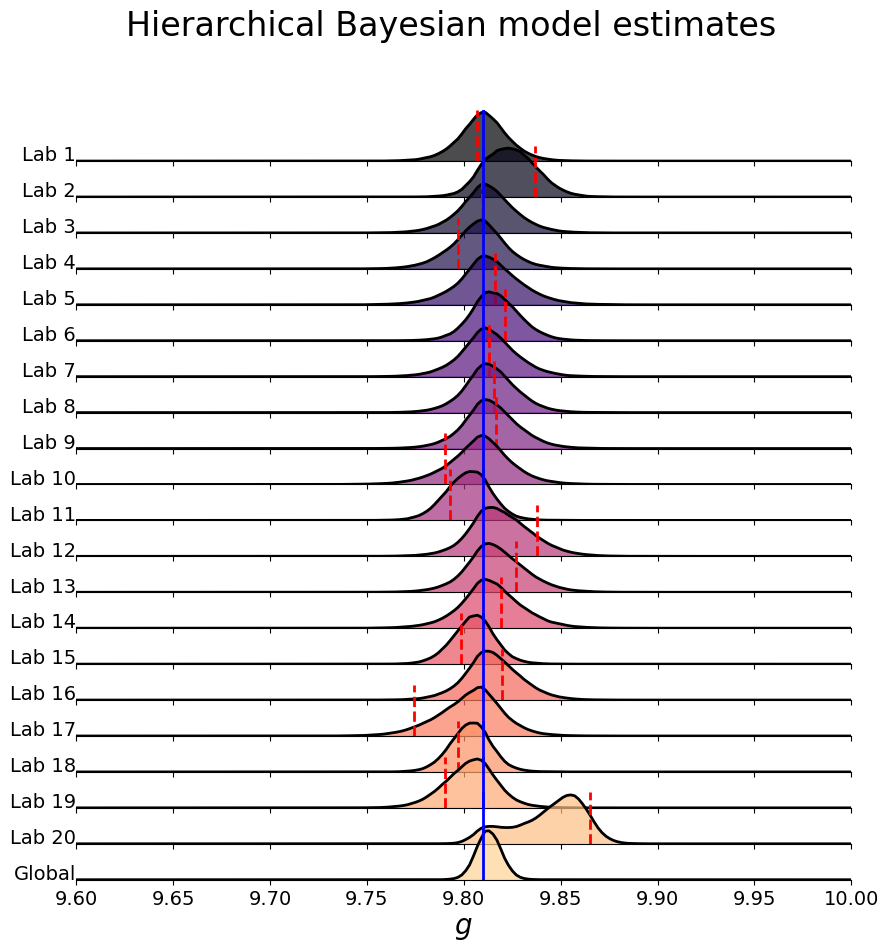

In [47]:
import matplotlib.gridspec as grid_spec
from scipy.stats import gaussian_kde

def ridge_plot(theta_samples, mu_samples, xlimits):
    """Make a ridge-plot figure.

    This function makes a ridge plot. It consists of a number of visually 
    overlapped smoothed histograms. It shows both the individual-level estimates
    as well as the hierarchical, global, estimate (last row). 
    
    The dashed lines indicate the observed treatment effects, while the 
    histograms show what our model estimates.

    Args:
        theta_samples: A numpy array of size J x num_samples x num_chains
        mu_samples: A numpy array of size 1 x num_samples x num_chains
        y: The observed treatment effects.
    """
    samples = np.concatenate([theta_samples, mu_samples], axis=0) #Объединяются массивы вдоль оси 0,чтобы получить общий массив samples, который содержит все выборки для всех параметров
    colors = plt.cm.get_cmap('magma')
    J = samples.shape[0] #колво графиков J = колву строк в массиве samples (т.е. колву параметров theta + 1 для mu)
    gs = grid_spec.GridSpec(J, 1) #сеткa графиков размером J x 1
    fig = plt.figure(figsize=(10, 10))

    i = 0
    xmin, xmax = xlimits
    theta = np.linspace(xmin, xmax, num=200)  #массив  из 200 точек, равномерно распределенных между xmin и xmax. Этот массив будет использоваться для построения графиков плотности.  

    ax_objs = [] #хранить объекты осей для каждого графика
    for i in range(J):
        pdf = gaussian_kde(samples[i, :, :].flatten()) #Для каждого параметра(/глобального) вычисляется оценка плотности распределения с использованием ядерной оценки плотности (KDE)
        posterior = pdf(theta) #Для каждого параметра (или глобального параметра) вычисляется оценка плотности распределения с использованием ядерной оценки плотности (KDE)

        # creating new axes object
        ax_objs.append(fig.add_subplot(gs[i:i+1, 0:])) #Этот объект осей будет использоваться для построения текущего графика

        # plotting the distribution
        ax_objs[-1].plot(theta, posterior, color='k', lw=2) #На текущем графике строится линия плотности распределения
        ax_objs[-1].fill_between(theta, np.zeros_like(theta), posterior, alpha=0.7, color=colors(i/(J+1))) #Закрашивается область под кривой плотности распределения


        # ADD MLE and Ground truth values
        mle_for_each_lab = [np.mean(lab) for lab in x]
        ground_truth = 9.81
        
        # ADD MLE in graph
        if i < len(mle_for_each_lab):
            ax_objs[-1].axvline(mle_for_each_lab[i], color='r', linestyle='--', lw=2)

        # ADD ground truthin graph
        ax_objs[-1].axvline(ground_truth, color='b', linestyle='-', lw=2)


        # setting uniform x and y lims
        ax_objs[-1].set_xlim(xmin, xmax) #Yстанавливаются границы оси X для текущего графика
        ax_objs[-1].set_ylim(bottom=0) #Устанавливается нижняя граница оси Y на 0

        # make background transparent
        rect = ax_objs[-1].patch
        rect.set_alpha(0) #Убирается фон текущего графика, делая его прозрачным. 

        # remove borders, axis ticks, and labels
        ax_objs[-1].set_yticklabels([]) #Убираются подписи на оси Y

        if i == J-1: #Если текущий график последний (глобальная оценка)
            ax_objs[-1].set_xlabel(r'$\theta_i$', fontsize=20) #добавляется подпись оси X и текст "Глобальная оценка"
            ax_objs[-1].text(xmin, 0.001, 'Global', fontsize=14, ha="right")
        else:
            ax_objs[-1].set_xticklabels([])            #убираются подписи оси X и добавляется текст с номером лаборатории
            ax_objs[-1].text(xmin, 0.001, f'Lab {i+1}',fontsize=14, ha="right")

        spines = ["top", "right", "left"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticks([]) #Убираются границы осей (верхняя, правая и левая) и убираются метки на оси Y

        i += 1

    ax_objs[-1].set_xlabel(r'$g$') #Для последнего графика добавляется подпись оси X
    gs.update(hspace=-0.3) #Обновляется расстояние между графиками, чтобы они перекрывались
    plt.suptitle('Hierarchical Bayesian model estimates', fontsize=24)
    plt.show()

#
xlimits = (9.6, 10.0) # left and right limits of the horizontal axis
ridge_plot(theta_samples, mu_samples, xlimits)

## Unexpected behaviour?

The result of the ridge plot should show the _shrinkage_ effect: for every lab, the distribution of $\theta_i$ should be nudged towards the _global_ mean, away from the MLE (and hopefully, _towards_ the true value of $g=9.81m/s^2$). This is the desired effect of hierarchical modelling; we now combine information from all the labs instead of treating them as completely independent.

However, maybe your figure does not show this behaviour! Instead, you might see one of two things, both having to do with the fact that we try to estimate the standard deviation across labs $\tau_\theta$. This is difficult, because the model can explain our observations in several ways:

- Either your estimates ignore the global mean and are pretty much centered at the MLE. This probably means $\sigma_\theta$ is too large (a.k.a. its distribution too wide).
- Alternatively, your estimates are (almost) identical to the global estimate. In this case, the distribution $\tau_\theta$ is probably too narrow: it explains the data by assuming all labs are almost perfect copies of each other, and that the variance in our data comes purely from the $\sigma_i$.

To solve this issue and actually see the desired effect, we can use very __un__informative priors for $\sigma_i$ and $\tau_\theta$. Try experimenting with uniform priors.

10. Tweak your hierarchical Bayesian model until you see the shrinkage effect. Describe the difference in your initial generative model and the one that you used in the end. If your model already shows the desired shrinking, you may skip this question (but please explain how you got that working first try...).

Visualization shows that the estimates of θi for each laboratory are "narrowed" to the global average of μθ. This is due to the hierarchical structure of the model, which takes into account both variation within laboratories and variation between laboratories.

Lastly, it is informative to create a similar ridge plot for all the parameters that represent variability in our model ($\sigma_i$ for each lab, as well as the variability between labs, $\sigma_\theta$). 

11. Create another ridge plot showing the distributions over these parameters. This time, the global estimate probably has a different expectation (= mean) than the distributions for the individual labs. Why is this the case? Hint: what is the difference in interpretation of $\sigma_i$ and $\sigma_\theta$?

In [61]:
import matplotlib.gridspec as grid_spec
from scipy.stats import gaussian_kde

def ridge_plot(theta_samples, mu_samples, xlimits):
    """Make a ridge-plot figure.

    This function makes a ridge plot. It consists of a number of visually 
    overlapped smoothed histograms. It shows both the individual-level estimates
    as well as the hierarchical, global, estimate (last row). 
    
    The dashed lines indicate the observed treatment effects, while the 
    histograms show what our model estimates.

    Args:
        theta_samples: A numpy array of size J x num_samples x num_chains
        mu_samples: A numpy array of size 1 x num_samples x num_chains
        y: The observed treatment effects.
    """
    samples = np.concatenate([theta_samples, mu_samples], axis=0) #Объединяются массивы вдоль оси 0,чтобы получить общий массив samples, который содержит все выборки для всех параметров
    colors = plt.cm.get_cmap('magma')
    J = samples.shape[0] #колво графиков J = колву строк в массиве samples (т.е. колву параметров theta + 1 для mu)
    gs = grid_spec.GridSpec(J, 1) #сеткa графиков размером J x 1
    fig = plt.figure(figsize=(10, 10))

    i = 0
    xmin, xmax = xlimits
    theta = np.linspace(xmin, xmax, num=200)  #массив  из 200 точек, равномерно распределенных между xmin и xmax. Этот массив будет использоваться для построения графиков плотности.  

    ax_objs = [] #хранить объекты осей для каждого графика
    for i in range(J):
        pdf = gaussian_kde(samples[i, :, :].flatten()) #Для каждого параметра(/глобального) вычисляется оценка плотности распределения с использованием ядерной оценки плотности (KDE)
        posterior = pdf(theta) #Для каждого параметра (или глобального параметра) вычисляется оценка плотности распределения с использованием ядерной оценки плотности (KDE)

        # creating new axes object
        ax_objs.append(fig.add_subplot(gs[i:i+1, 0:])) #Этот объект осей будет использоваться для построения текущего графика

        # plotting the distribution
        ax_objs[-1].plot(theta, posterior, color='k', lw=2) #На текущем графике строится линия плотности распределения
        ax_objs[-1].fill_between(theta, np.zeros_like(theta), posterior, alpha=0.7, color=colors(i/(J+1))) #Закрашивается область под кривой плотности распределения


        # setting uniform x and y lims
        ax_objs[-1].set_xlim(xmin, xmax) #Yстанавливаются границы оси X для текущего графика
        ax_objs[-1].set_ylim(bottom=0) #Устанавливается нижняя граница оси Y на 0

        # make background transparent
        rect = ax_objs[-1].patch
        rect.set_alpha(0) #Убирается фон текущего графика, делая его прозрачным. 

        # remove borders, axis ticks, and labels
        ax_objs[-1].set_yticklabels([]) #Убираются подписи на оси Y

        if i == J-1: #Если текущий график последний (глобальная оценка)
            ax_objs[-1].set_xlabel(r'$\theta_i$', fontsize=20) #добавляется подпись оси X и текст "Глобальная оценка"
            ax_objs[-1].text(xmin, 0.001, 'Global', fontsize=14, ha="right")
        else:
            ax_objs[-1].set_xticklabels([])            #убираются подписи оси X и добавляется текст с номером лаборатории
            ax_objs[-1].text(xmin, 0.001, f'Lab {i+1}',fontsize=14, ha="right")

        spines = ["top", "right", "left"]
        for s in spines:
            ax_objs[-1].spines[s].set_visible(False)
        ax_objs[-1].set_yticks([]) #Убираются границы осей (верхняя, правая и левая) и убираются метки на оси Y

        i += 1

    ax_objs[-1].set_xlabel(r'$g$') #Для последнего графика добавляется подпись оси X
    gs.update(hspace=-0.3) #Обновляется расстояние между графиками, чтобы они перекрывались
    plt.suptitle('Hierarchical Bayesian model estimates', fontsize=24)
    plt.show()


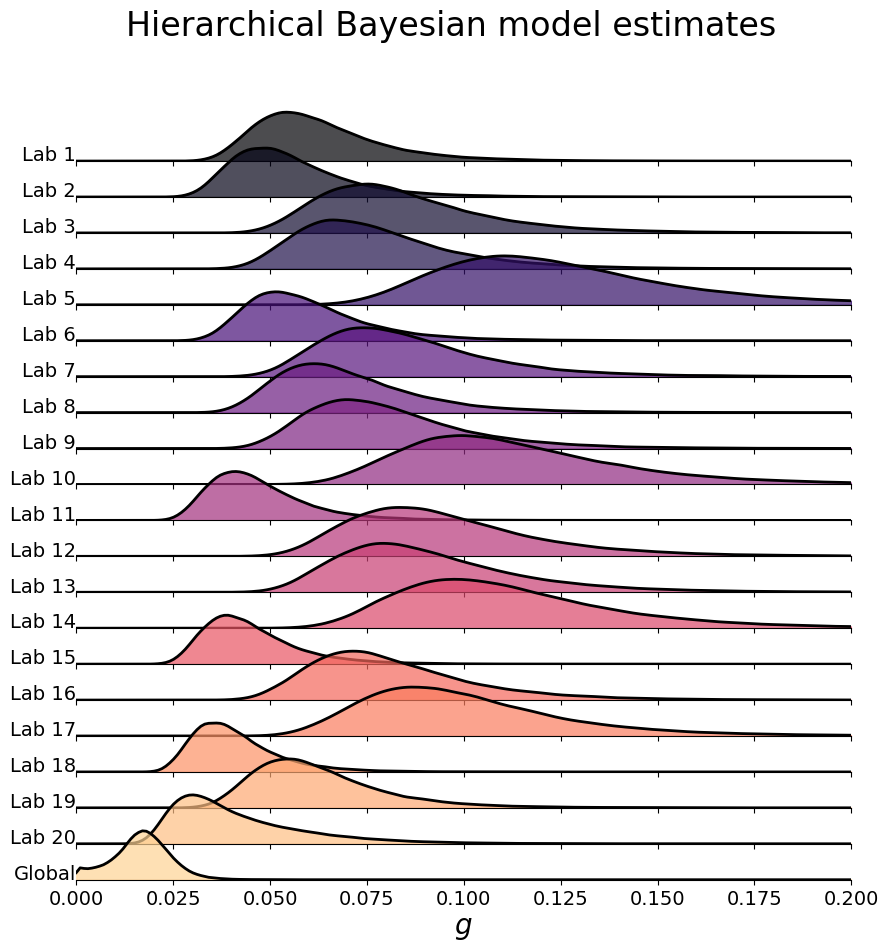

In [65]:
xlimits = (0, 0.2)
ridge_plot(sigma_samples, sigma_theta_samples, xlimits)

σi is the standard deviation of measurements inside laboratory i.
σθ is the standard deviation between laboratories.

The global value σθ is usually less than σi, as it reflects variation between laboratories rather than within them.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4400a066-fc8e-4fd4-bdba-c70304927a8d' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>